In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


train_df = pd.read_csv("data\\train.csv")
test_df = pd.read_csv("data\\test.csv")

In [11]:
def count_name(full_name):
    return len(full_name.split())

train_df['name_length'] = train_df['full_name'].apply(count_name)
test_df['name_length'] = test_df['full_name'].apply(count_name)

In [12]:
def is_pac(full_name):
    pac_words = ['friends', 'pac', 'committee', 'fund', 'citizens']
    name_list = full_name.split()
    for i in name_list:
        if i in pac_words:
            return 1
    return 0

train_df['is_pac_name'] = train_df['full_name'].apply(is_pac)
test_df['is_pac_name'] = test_df['full_name'].apply(is_pac)

In [13]:
def is_org(full_name):
    org_words = ['inc', 'llc', 'corp', 'ltd', 'company', 'corporation', 'co', 'c/o', 'foundation', 'association', 'trust', '&']
    name_list = full_name.split()
    for i in name_list:
        if i in org_words:
            return 1
    return 0

train_df['is_org_name'] = train_df['full_name'].apply(is_org)
test_df['is_org_name'] = test_df['full_name'].apply(is_org)

In [14]:
X_train = train_df[['name_length', 'is_pac_name', 'is_org_name']]
y_train = train_df['label']

X_test = test_df[['name_length', 'is_pac_name', 'is_org_name']]
y_test = test_df['label']

In [15]:
rfc = RandomForestClassifier(random_state = 1)
rfc.fit(X_train, y_train)
predicted = rfc.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, predicted) * 100

recall = recall_score(y_test, predicted) * 100

precision = precision_score(y_test, predicted) * 100

f1= f1_score(y_test, predicted) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_test, predicted))

Accuracy: 73.82226282134934
Recall: 94.46764091858037
Precision: 66.86368673808644
f1_score: 78.30413151633138

              precision    recall  f1-score   support

           0       0.91      0.53      0.67     19155
           1       0.67      0.94      0.78     19160

    accuracy                           0.74     38315
   macro avg       0.79      0.74      0.73     38315
weighted avg       0.79      0.74      0.73     38315



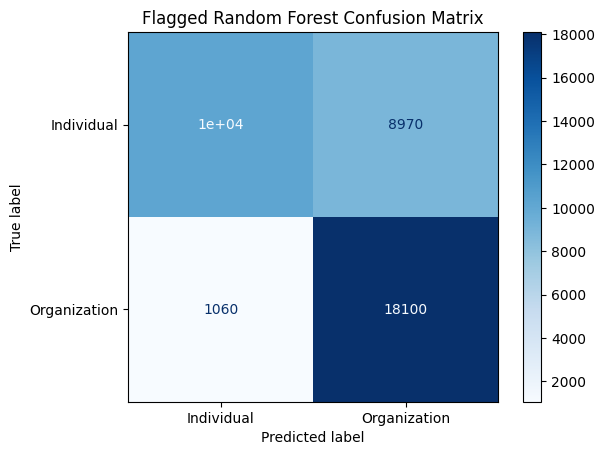

In [ ]:
cm = confusion_matrix(y_test, predicted, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Flagged Random Forest Confusion Matrix')
#plt.savefig('Flagged Random Forest Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()